训练集映射后NaN: 0
测试集映射后NaN: 0
Epoch [1/20], Loss: 0.2677
Epoch [2/20], Loss: 0.1350
Epoch [3/20], Loss: 0.1200
Epoch [4/20], Loss: 0.1150
Epoch [5/20], Loss: 0.0956
Epoch [6/20], Loss: 0.0878
Epoch [7/20], Loss: 0.0811
Epoch [8/20], Loss: 0.0743
Epoch [9/20], Loss: 0.0798
Epoch [10/20], Loss: 0.0752
Epoch [11/20], Loss: 0.0673
Epoch [12/20], Loss: 0.0700
Epoch [13/20], Loss: 0.0637
Epoch [14/20], Loss: 0.0694
Epoch [15/20], Loss: 0.0691
Epoch [16/20], Loss: 0.0677
Epoch [17/20], Loss: 0.0678
Epoch [18/20], Loss: 0.0702
Epoch [19/20], Loss: 0.0589
Epoch [20/20], Loss: 0.0572
总体准确率: 0.7816713981547196
              precision    recall  f1-score   support

      normal       0.71      0.93      0.80      9711
         DoS       0.91      0.85      0.88      7458
       Probe       0.85      0.73      0.78      2421
         R2L       0.93      0.16      0.28      2887
         U2R       0.14      0.54      0.22        67

    accuracy                           0.78     22544
   macro avg     

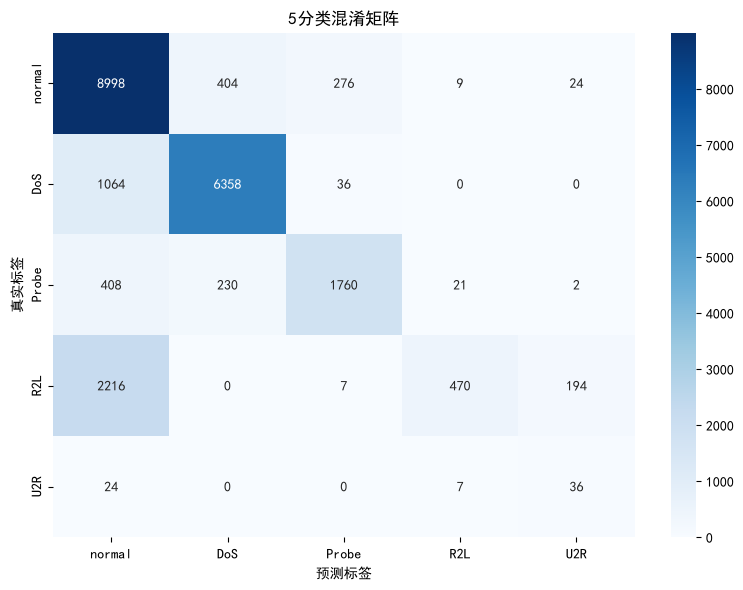

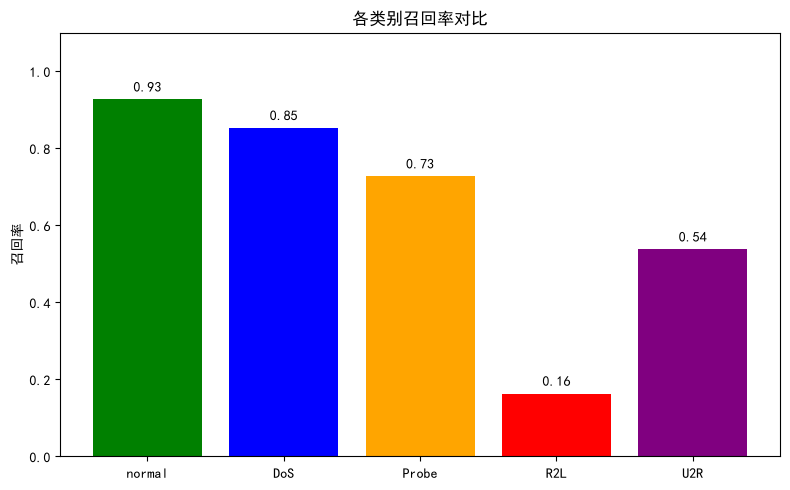

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, recall_score
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False


columns = ['duration','protocol_type','service','flag','src_bytes','dst_bytes','land','wrong_fragment','urgent','hot','num_failed_logins','logged_in','num_compromised','root_shell','su_attempted','num_root','num_file_creations','num_shells','num_access_files','num_outbound_cmds','is_host_login','is_guest_login','count','srv_count','serror_rate','srv_serror_rate','rerror_rate','srv_rerror_rate','same_srv_rate','diff_srv_rate','srv_diff_host_rate','dst_host_count','dst_host_srv_count','dst_host_same_srv_rate','dst_host_diff_srv_rate','dst_host_same_src_port_rate','dst_host_srv_diff_host_rate','dst_host_serror_rate','dst_host_srv_serror_rate','dst_host_rerror_rate','dst_host_srv_rerror_rate','label','difficulty']

df_train = pd.read_csv('data/KDDTrain+.txt', header=None, names=columns)
df_test = pd.read_csv('data/KDDTest+.txt', header=None, names=columns)

label_map = {
    'normal': 0,
    'neptune': 1, 'smurf': 1, 'back': 1, 'teardrop': 1, 'pod': 1, 'land': 1,
    'apache2': 1, 'udpstorm': 1, 'processtable': 1, 'mailbomb': 1,
    'satan': 2, 'ipsweep': 2, 'nmap': 2, 'portsweep': 2, 'mscan': 2, 'saint': 2,
    'warezclient': 3, 'warezmaster': 3, 'ftp_write': 3, 'imap': 3, 'phf': 3, 'multihop': 3, 'guess_passwd': 3, 'spy': 3,
    'snmpgetattack': 3, 'snmpguess': 3, 'httptunnel': 3, 'named': 3, 'sendmail': 3, 'worm': 3, 'xlock': 3, 'xsnoop': 3,
    'buffer_overflow': 4, 'loadmodule': 4, 'rootkit': 4, 'perl': 4, 'ps': 4, 'sqlattack': 4, 'xterm': 4
}

df_train['label_5class'] = df_train['label'].map(label_map)
df_test['label_5class'] = df_test['label'].map(label_map)

print("训练集映射后NaN:", df_train['label_5class'].isna().sum())
print("测试集映射后NaN:", df_test['label_5class'].isna().sum())

df_combined = pd.concat([df_train, df_test], axis=0)
df_combined = pd.get_dummies(df_combined, columns=['protocol_type','service','flag'])
df_train = df_combined.iloc[:len(df_train)].copy()
df_test = df_combined.iloc[len(df_train):].copy()

X_train = df_train.drop(['label','difficulty','label_5class'], axis=1).values
y_train = df_train['label_5class'].values.astype(int)
X_test = df_test.drop(['label','difficulty','label_5class'], axis=1).values
y_test = df_test['label_5class'].values.astype(int)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

class_counts = np.bincount(y_train)
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum() * len(class_counts)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

class MLP5(nn.Module):
    def __init__(self, input_dim):
        super(MLP5, self).__init__()
        self.fc1 = nn.Linear(input_dim, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 5)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.3)
    def forward(self, x):
        x = self.dropout(self.relu(self.fc1(x)))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)
        return x

input_dim = X_train_scaled.shape[1]
model = MLP5(input_dim).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer = optim.Adam(model.parameters(), lr=0.001)

model.train()
for epoch in range(20):
    running_loss = 0.0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    print(f'Epoch [{epoch+1}/20], Loss: {running_loss/len(train_loader):.4f}')

model.eval()
all_preds = []
all_labels = []
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

y_pred = np.array(all_preds)
y_true = np.array(all_labels)

print("总体准确率:", accuracy_score(y_true, y_pred))
print(classification_report(y_true, y_pred, target_names=['normal','DoS','Probe','R2L','U2R']))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['normal','DoS','Probe','R2L','U2R'], yticklabels=['normal','DoS','Probe','R2L','U2R'])
plt.title('5分类混淆矩阵')
plt.xlabel('预测标签')
plt.ylabel('真实标签')
plt.tight_layout()
plt.show()

recalls = recall_score(y_true, y_pred, average=None)
plt.figure(figsize=(8, 5))
plt.bar(['normal','DoS','Probe','R2L','U2R'], recalls, color=['green','blue','orange','red','purple'])
plt.title('各类别召回率对比')
plt.ylabel('召回率')
plt.ylim(0, 1.1)
for i, v in enumerate(recalls):
    plt.text(i, v + 0.02, f'{v:.2f}', ha='center')
plt.tight_layout()
plt.show()












